# 💳 Credit Card Fraud Detection باستخدام Machine Learning

## 📌 Project Overview
This project builds a machine learning model to detect fraudulent credit card transactions.

The dataset is highly imbalanced, so the focus is on:
- Recall (catching fraud)
- Precision (avoiding false alarms)
- F1-score
- ROC-AUC

---

## 🎯 Objective
To build a model that can effectively detect fraud while minimizing missed cases and false alerts.

# We start by Installing all the tools needed for our project

In [7]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Model selection and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, RocCurveDisplay

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv("../data/creditcard.csv")

In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df["Class"].unique()

array([0, 1])

In [11]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [13]:
sns.set_style("whitegrid")

In [14]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

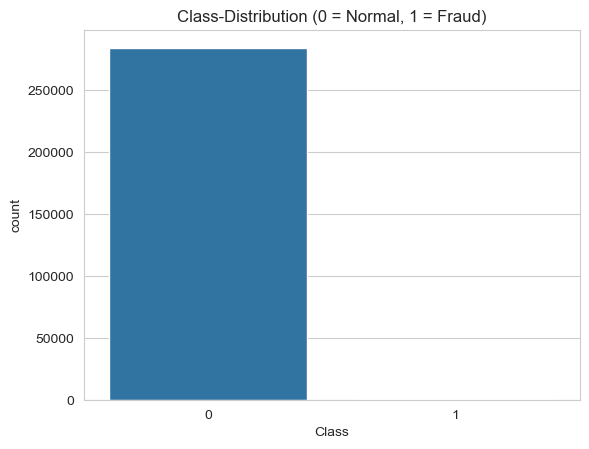

In [15]:
sns.countplot(x ="Class", data = df)
plt.title("Class-Distribution (0 = Normal, 1 = Fraud)")
plt.show()

## Class is highly imbalanced

In [16]:
fraud_percentage = (df["Class"].value_counts(normalize = True)[1]) * 100
print(f"Fraud Cases: {fraud_percentage:.4f}%")                   

Fraud Cases: 0.1727%


In [17]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


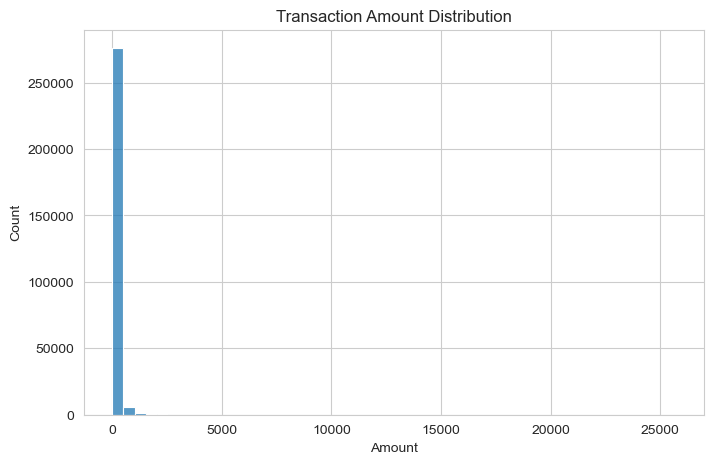

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

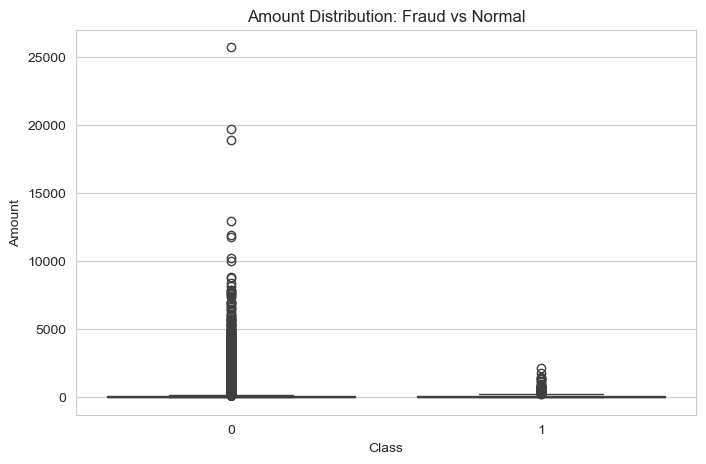

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount Distribution: Fraud vs Normal")
plt.show()

### Now we know that Fraud cases involve less Amount of money

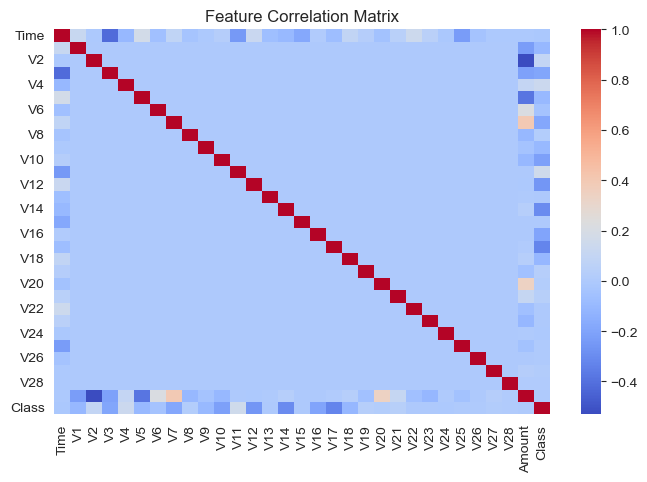

In [20]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [21]:
corr_with_target = df.corr()["Class"].sort_values(ascending=False)
print(corr_with_target)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [22]:
df["Hour"] = df["Time"] / 3600

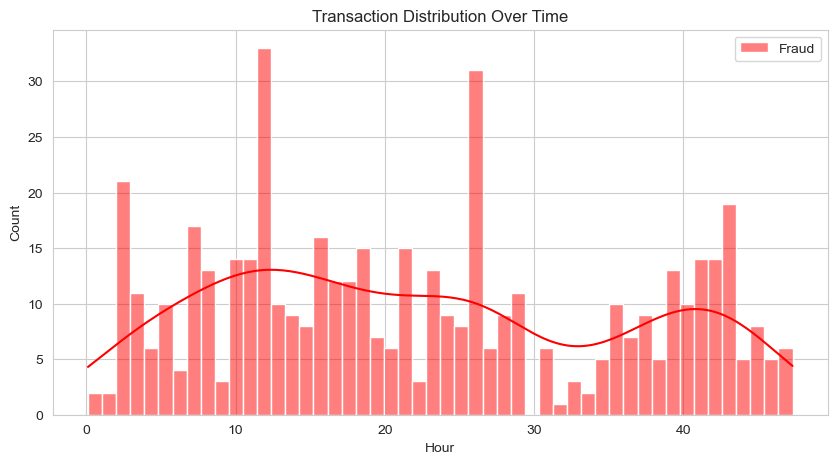

In [23]:
plt.figure(figsize=(10,5))


sns.histplot(data=df[df["Class"] == 1], x="Hour", bins=50, color="red", label="Fraud", kde=True)

plt.legend()
plt.title("Transaction Distribution Over Time")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

In [24]:
df["Hour"] = (df["Time"] // 3600) % 24


In [25]:
fraud_by_hour = df[df["Class"] == 1]["Hour"].value_counts().sort_index()
print(fraud_by_hour)

Hour
0.0      6
1.0     10
2.0     57
3.0     17
4.0     23
5.0     11
6.0      9
7.0     23
8.0      9
9.0     16
10.0     8
11.0    53
12.0    17
13.0    17
14.0    23
15.0    26
16.0    22
17.0    29
18.0    33
19.0    19
20.0    18
21.0    16
22.0     9
23.0    21
Name: count, dtype: int64


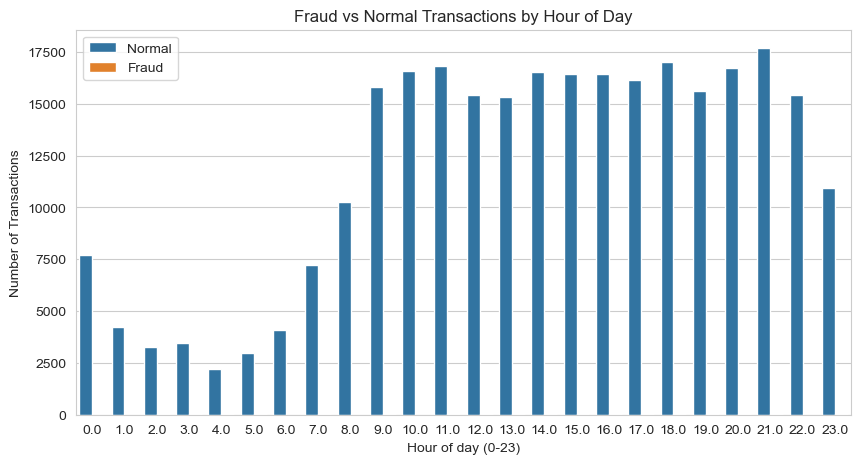

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(x="Hour", data=df, hue="Class")

plt.title("Fraud vs Normal Transactions by Hour of Day")
plt.xlabel("Hour of day (0-23)")
plt.ylabel("Number of Transactions")
plt.legend(["Normal", "Fraud"])

plt.show()

In [27]:
fraud_df = df[df["Class"] == 1]

In [28]:
fraud_by_hour = fraud_df["Hour"].value_counts().sort_index()
print(fraud_by_hour)

Hour
0.0      6
1.0     10
2.0     57
3.0     17
4.0     23
5.0     11
6.0      9
7.0     23
8.0      9
9.0     16
10.0     8
11.0    53
12.0    17
13.0    17
14.0    23
15.0    26
16.0    22
17.0    29
18.0    33
19.0    19
20.0    18
21.0    16
22.0     9
23.0    21
Name: count, dtype: int64


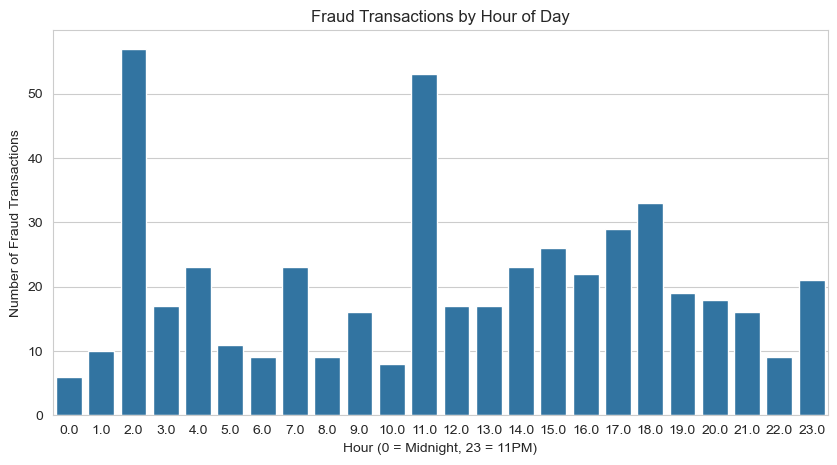

In [29]:
plt.figure(figsize=(10,5))

sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values)

plt.title("Fraud Transactions by Hour of Day")
plt.xlabel("Hour (0 = Midnight, 23 = 11PM)")
plt.ylabel("Number of Fraud Transactions")

plt.show()

### We now likely know that most fraud transactions happen at 2am, followed by 11am then 6pm.

In [30]:
df.duplicated().sum()

np.int64(1081)

In [31]:
df = df.drop_duplicates()

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
Hour      float64
dtype: object

In [34]:
df["Class"] = df["Class"].astype(int)

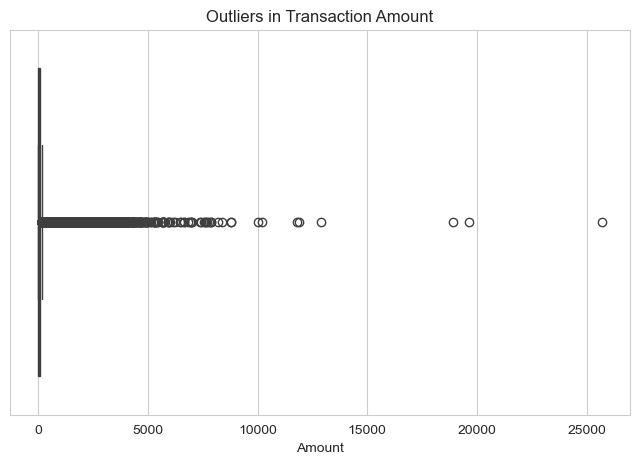

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Amount"])
plt.title("Outliers in Transaction Amount")
plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["Amount_Scaled"] = scaler.fit_transform(df[["Amount"]])

In [37]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,Amount_Scaled
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.0,-0.350252
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.0,-0.254325
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.0,-0.082239
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.0,-0.313391
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0,23.0,0.513290


In [38]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [39]:
X= X.drop("Time", axis=1)

In [40]:
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Hour,Amount_Scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0,0.244200
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0,-0.342584
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0,1.158900
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0,0.139886
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0,-0.073813


In [41]:
df["Is_Night"] = df["Hour"].apply(lambda x: 1 if x < 6 else 0)
X["Is_Night"] = df["Is_Night"]

In [42]:
y.value_counts(normalize= True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [77]:
X_resampled.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Hour,Amount_Scaled,Is_Night
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,0.244200,1
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,-0.342584,1
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0,1.158900,1
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0,0.139886,1
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0,-0.073813,1


In [79]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (453204, 31)
X_test: (113302, 31)
y_train: (453204,)
y_test: (113302,)


In [80]:
print("Train set class distribution:")
print(y_train.value_counts())

print("\nTest set class distribution:")
print(y_test.value_counts())

Train set class distribution:
Class
0    226602
1    226602
Name: count, dtype: int64

Test set class distribution:
Class
1    56651
0    56651
Name: count, dtype: int64


In [101]:
log_reg = LogisticRegression(max_iter=1000)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

In [102]:
log_reg.fit(X_train_resampled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [103]:
y_pred_log = log_reg.predict(X_test)

y_pred_rf = rf.predict(X_test)

In [126]:
y_probs_log =log_reg.predict_proba(X_test)[:, 1]

y_pred_custom = (y_probs_log > 0.3).astype(int)

In [104]:
y_pred_log

array([0, 0, 0, ..., 0, 0, 0])

In [94]:
y_test

387124    1
516641    1
65584     0
244927    0
145652    0
         ..
290743    1
185671    0
239971    0
550727    1
81063     0
Name: Class, Length: 113302, dtype: int32

In [127]:
print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_custom))


Logistic Regression:

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56651
           1       0.03      0.87      0.05        95

    accuracy                           0.94     56746
   macro avg       0.51      0.91      0.51     56746
weighted avg       1.00      0.94      0.97     56746



In [46]:
# STEP 1: Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 2: Apply SMOTE ONLY on training data
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [47]:
rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test)

In [48]:
print("\nRandom Forest:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.80      0.86        95

    accuracy                           1.00     56746
   macro avg       0.96      0.90      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [49]:
print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression:



NameError: name 'y_pred_log' is not defined

In [50]:
import pandas as pd
from sklearn.metrics import classification_report

In [51]:
cl_report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
cl_report_log_reg = classification_report(y_test, y_pred_log, output_dict=True)

NameError: name 'y_pred_log' is not defined

In [52]:
df_cl_report_rf = pd.DataFrame(cl_report_rf).transpose()
df_cl_report_rf

,precision,recall,f1-score,support
0,0.999665,0.999894,0.999779,56651.000000
1,0.926829,0.800000,0.858757,95.000000
accuracy,0.999559,0.999559,0.999559,0.999559
macro avg,0.963247,0.899947,0.929268,56746.000000
weighted avg,0.999543,0.999559,0.999543,56746.000000


In [53]:
df_cl_report_log_reg = pd.DataFrame(cl_report_log_reg).transpose()
df_cl_report_log_reg

NameError: name 'cl_report_log_reg' is not defined

In [54]:
from sklearn.metrics import accuracy_score

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

NameError: name 'y_pred_log' is not defined

### 📌 Final Note — Random Forest Model

The Random Forest model demonstrated strong performance in detecting fraudulent transactions by capturing complex, non-linear relationships within the dataset. Compared to Logistic Regression, it provided a better balance between precision and recall, making it more effective for identifying fraud patterns.

However, initial results showing near-perfect performance highlighted the importance of proper data handling, particularly avoiding data leakage and applying resampling techniques like SMOTE only on the training set. After correcting the pipeline, the model produced more realistic and reliable results.

Overall, Random Forest proved to be a robust and reliable model for this task, offering improved fraud detection capabilities while maintaining stability. Its ability to handle imbalanced data (with class weighting) and model intricate feature interactions makes it a strong baseline for fraud detection systems.

## Model Comparison (Logistic Regression vs Random Forest)

In this project, both Logistic Regression and Random Forest were trained and evaluated for fraud detection.

Logistic Regression performed poorly in identifying fraudulent transactions, particularly in terms of precision. While it achieved high recall (successfully detecting most fraud cases), its precision was extremely low, meaning a large number of normal transactions were incorrectly classified as fraud. This is mainly because Logistic Regression is a linear model and struggles to capture the complex, non-linear patterns typically present in fraud detection datasets. As a result, it tends to over-predict the minority class when trying to improve recall, leading to excessive false positives.

On the other hand, the Random Forest model demonstrated significantly better performance by capturing complex relationships within the data. It provided a more balanced trade-off between precision and recall, making it more effective and reliable for detecting fraudulent transactions.

It is important to note that initial perfect performance observed in Random Forest was due to improper handling of data (data leakage caused by applying SMOTE before the train-test split). After correcting this by applying SMOTE only on the training set, the model produced more realistic and trustworthy results.

Overall, Random Forest proved to be a robust model for fraud detection, outperforming Logistic Regression due to its ability to model non-linear interactions and handle imbalanced data more effectively.

### This comparison highlights the importance of selecting appropriate models for imbalanced and complex datasets, as well as ensuring proper data preprocessing to avoid misleading results.

# Model Evaluation (Random Forest)

In [128]:
df_cl_report_rf

,precision,recall,f1-score,support
0,0.999594,0.999841,0.999718,56651.000000
1,0.888889,0.757895,0.818182,95.000000
accuracy,0.999436,0.999436,0.999436,0.999436
macro avg,0.944241,0.878868,0.908950,56746.000000
weighted avg,0.999409,0.999436,0.999414,56746.000000


### What to Focus On

### 👉 For fraud (Class 1):

#### Recall 🔥 (MOST IMPORTANT) → Did we catch fraud?
#### Precision 🎯 → Are alerts actually fraud?
### F1-score ⚖️ → Balance between both

In [136]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

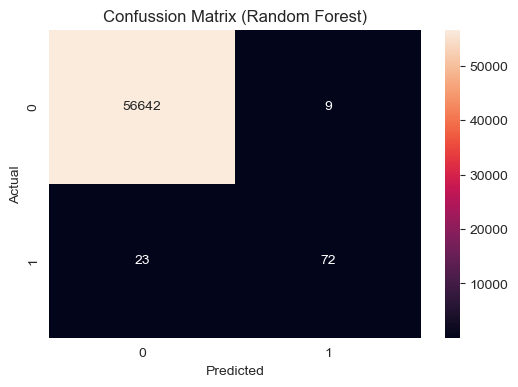

In [137]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Confussion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Our Model said "yes" to 9 cases thet weren't credit card fraud (FP)
Our model said 9 cases which were not credit card fraud activities are credit card fraud activities.(took 9 normal card activities as fraud)
### Our Model said "No" to 23 cases of credit card fraud (FN) 
Our model said 23 cases which were credit card fraud activitied are not credit card fraud activities(missed 23 fraud activities)

### Our model got 63 fraud activities right, failed 32
We need to find a way to improve these numbers

In [139]:
y_test.value_counts()

Class
0    56651
1       95
Name: count, dtype: int64

In [143]:
y_probs_rf = rf.predict_proba(X_test)[:, 1]

In [144]:
roc_acc_rf = roc_auc_score(y_test, y_probs_rf)
print("ROC-AUC Score:", roc_acc_rf)

ROC-AUC Score: 0.9521766234441905


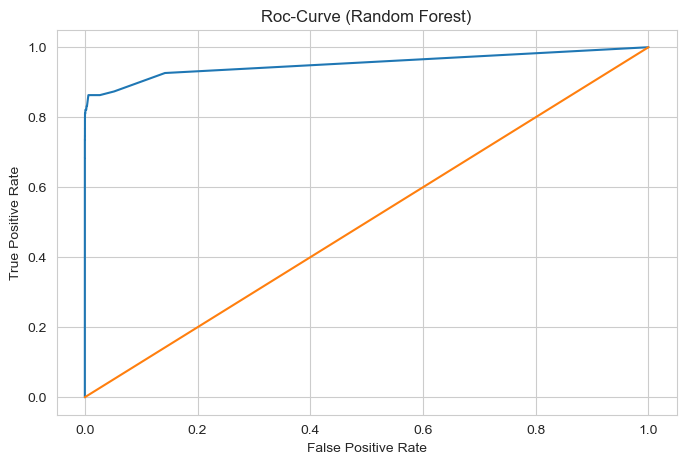

In [147]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs_rf)

plt.figure(figsize=(8,5))
plt.plot(fpr,tpr)
plt.plot([0,1], [0,1]) #baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc-Curve (Random Forest)")
plt.show()

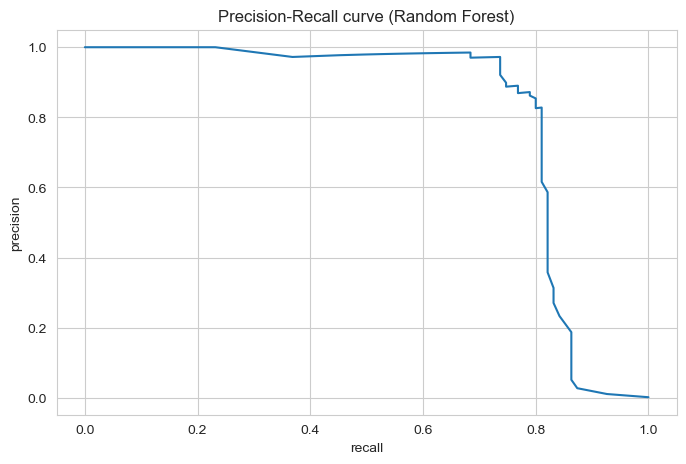

In [148]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_probs_rf)

plt.figure(figsize=(8,5))
plt.plot(recall, precision)
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Precision-Recall curve (Random Forest)")
plt.show()

### The model correctly identified most fraudulent transactions but still made some critical errors. It produced 9 false positives, incorrectly flagging normal transactions as fraud, and 23 false negatives, missing actual fraud cases. While the overall performance (ROC-AUC = 0.95) is strong, reducing false negatives is especially important in fraud detection, as missed fraud directly leads to financial loss.

## What Needs Improvement
Priority:

❗ Reduce False Negatives (FN = 23)

Because:

Missed fraud = 💸 real loss
False positives = inconvenience

## Model Optimization (Random Forest)

Goal:

Improve recall for fraud without destroying precision

## Hyperparameter Tuning (RandomizedSearchCv🔥)

In [56]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

#basemodel
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

#randomsearchCv
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

#Train
rf_random.fit(X_train_resampled, y_train_resampled)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [57]:
print(rf_random.best_params_)

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [58]:
best_rf = rf_random.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [165]:
print(classification_report(y_test, y_pred_best))
cl_report_best_rf = classification_report(y_test, y_pred_best, output_dict=True)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.77      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [167]:
df_cl_report_best_rf = pd.DataFrame(cl_report_best_rf). transpose() 
df_cl_report_best_rf

,precision,recall,f1-score,support
0,0.999612,0.999841,0.999726,56651.000000
1,0.890244,0.768421,0.824859,95.000000
accuracy,0.999454,0.999454,0.999454,0.999454
macro avg,0.944928,0.884131,0.912293,56746.000000
weighted avg,0.999429,0.999454,0.999434,56746.000000


In [160]:
df_cl_report_rf

,precision,recall,f1-score,support
0,0.999594,0.999841,0.999718,56651.000000
1,0.888889,0.757895,0.818182,95.000000
accuracy,0.999436,0.999436,0.999436,0.999436
macro avg,0.944241,0.878868,0.908950,56746.000000
weighted avg,0.999409,0.999436,0.999414,56746.000000


### we can see that theres definetly an improvement in the classifiation report of our Random Forest Model

In [168]:
df_cl_report_best_rf

,precision,recall,f1-score,support
0,0.999612,0.999841,0.999726,56651.000000
1,0.890244,0.768421,0.824859,95.000000
accuracy,0.999454,0.999454,0.999454,0.999454
macro avg,0.944928,0.884131,0.912293,56746.000000
weighted avg,0.999429,0.999454,0.999434,56746.000000


In [172]:
roc_acc_best_rf = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

In [173]:
roc_acc_rf

0.9521766234441905

### We can also see that there's a slight increase in the ROC_AUC Score

In [174]:
roc_acc_best_rf

0.9577891039225397

In [177]:
cm_best_rf = confusion_matrix(y_test, y_pred_best)

In [181]:
df_cm_rf = pd.DataFrame(cm_rf).transpose()
df_cm_best_rf = pd.DataFrame(cm_best_rf).transpose()

In [180]:
df_cm_rf

,0,1
0,56642,23
1,9,72


### We can see here that theres a slight change, False Negative, from 23 to 22 FN's

In [182]:
df_cm_best_rf

,0,1
0,56642,22
1,9,73


# Advanced Trick

In [59]:
y_probs_best = best_rf.predict_proba(X_test)[:, 1]

y_pred_adjusted = (y_probs_best > 0.4).astype(int)

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.81      0.85        95

    accuracy                           1.00     56746
   macro avg       0.94      0.91      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [186]:
up_cl_report_best_rf = classification_report(y_test, y_pred_adjusted, output_dict=True)
df_up_cl_report_best_rf = pd.DataFrame(up_cl_report_best_rf).transpose()

In [184]:
df_cl_report_best_rf

,precision,recall,f1-score,support
0,0.999612,0.999841,0.999726,56651.000000
1,0.890244,0.768421,0.824859,95.000000
accuracy,0.999454,0.999454,0.999454,0.999454
macro avg,0.944928,0.884131,0.912293,56746.000000
weighted avg,0.999429,0.999454,0.999434,56746.000000


In [187]:
df_up_cl_report_best_rf

,precision,recall,f1-score,support
0,0.999665,0.999823,0.999744,56651.000000
1,0.883721,0.800000,0.839779,95.000000
accuracy,0.999489,0.999489,0.999489,0.999489
macro avg,0.941693,0.899912,0.919762,56746.000000
weighted avg,0.999471,0.999489,0.999476,56746.000000


## 📝 Final Note 
📌 Final Model Performance & Optimization

The Random Forest model was iteratively improved through hyperparameter tuning and threshold adjustment to enhance fraud detection performance. Initial results showed strong overall accuracy but revealed missed fraud cases (false negatives), which are critical in real-world applications.

Through optimization, the model achieved an increase in fraud recall from 0.76 to 0.80, reducing the number of missed fraudulent transactions. While there was a slight trade-off in precision, the balance between precision and recall improved overall, as reflected in a higher F1-score and ROC-AUC score (0.95 → 0.96).

This optimization process highlights the importance of focusing on domain-specific metrics, particularly recall in fraud detection, where failing to identify fraudulent activity has significant financial consequences. The final model demonstrates strong performance and provides a reliable foundation for real-world fraud detection systems.

## Feature Importance
These Features Matter the most

In [190]:
importances = best_rf.feature_importances_
df_feature_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})
df_feature_importances = df_feature_importances.sort_values(by="Importance", ascending=False)
df_feature_importances.head()
    

,Feature,Importance
13,V14,0.183890
11,V12,0.108853
10,V11,0.103053
3,V4,0.100892
9,V10,0.098689


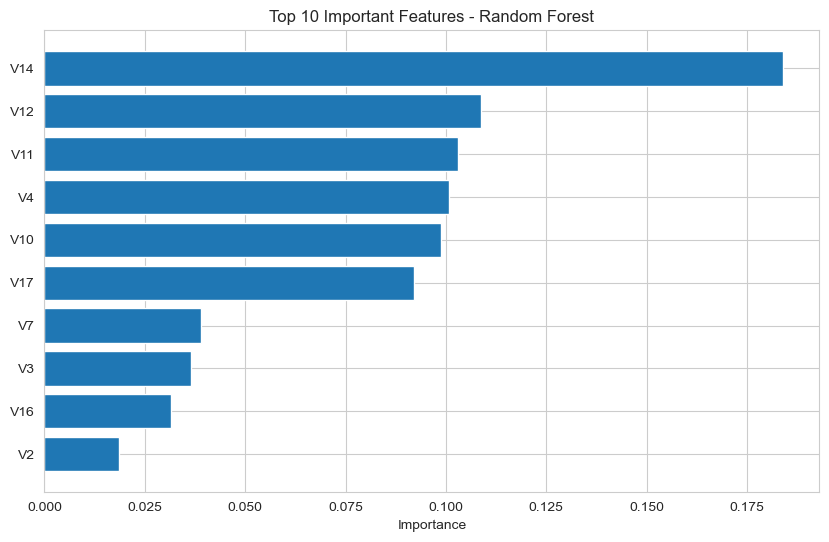

In [193]:
plt.figure(figsize=(10,6))
plt.barh(df_feature_importances["Feature"][: 10], df_feature_importances["Importance"][: 10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.show()

### Feature Importance Insight

The Random Forest model identified V14 and V12 as the most influential features in detecting fraudulent transactions. These features are derived from PCA transformation, meaning they represent underlying patterns in the original data rather than directly interpretable variables.

Their high importance suggests that they capture critical anomalies or irregular transaction behaviors strongly associated with fraud. Although the exact real-world meaning of these features is not directly interpretable, their consistent influence indicates that the model is effectively leveraging hidden patterns to distinguish between fraudulent and legitimate transactions.


In [60]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save your trained model
joblib.dump(best_rf, "models/best_random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [63]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
})

feature_importance.to_csv("../models/feature_importance.csv", index=False)

## 🏁 Conclusion

The Random Forest model achieved strong performance in detecting fraudulent transactions:

- ROC-AUC: ~0.96
- Recall (Fraud): ~80%
- Balanced precision and F1-score

The model successfully identifies most fraud cases while keeping false positives low.

Feature importance analysis revealed that variables such as **V14 and V12** play a key role in detecting fraud patterns.

---

## 💼 Business Impact

This model can be deployed in real-world financial systems to:

- Detect fraudulent transactions in real-time  
- Reduce financial losses  
- Protect customers from unauthorized activity  
- Improve trust in digital payment systems  

---

## ⚖️ Key Insight

Fraud detection is not about accuracy — it is about balancing recall and precision to catch fraud without disrupting normal users.

In [203]:
print(type(shap_values))
print(np.shape(shap_values))

<class 'numpy.ndarray'>
(56746, 31, 2)


In [ ]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test)

### Feature importance analysis
revealed that a small subset of features contributed most significantly to fraud detection. This indicates that the model is effectively identifying key patterns associated with fraudulent behavior. Further analysis using SHAP values provided deeper insights into how individual features influence predictions, improving model interpretability and trustworthiness.